# Multi-Objective Optimizer Benchmark — 5-Way Comparison

Head-to-head of five NSGA-II implementations on identical problems:

| library | what it is |
|---|---|
| **rustypus (native)** | the Rust crate, pure-Rust objective (no FFI) — measured via its example binaries |
| **rustypus (py)** | the same Rust engine driven from Python through the pyo3 bindings (Python-callable objective; every eval crosses the GIL) |
| **pymoo** | NumPy-vectorized NSGA-II with compiled operators |
| **platypus** | pure-Python NSGA-II |
| **DEAP** | NSGA-II hand-assembled from DEAP primitives |

We compare **wall-clock time**, **peak memory**, and **solution quality** on two problems:
ZDT1 (2 objectives) and DTLZ2 (3 objectives).

### Quality metrics
- **IGD** (Inverted Generational Distance) — for each point on the *true* Pareto front, distance to
  the nearest solution found, averaged. Rewards convergence **and** coverage. **Lower is better; 0 = perfect.**
- **HV** (Hypervolume) — volume of objective space dominated by the found front, bounded by a fixed
  reference point just beyond it. Rewards getting close **and** spreading out; needs no true front.
  **Higher is better.**

Both are computed *identically* for every library (via pymoo's indicators for DTLZ2) so the
comparison is fair. Run this notebook from the `sandbox/` directory with the `Python 3 (rustypus)` kernel.

In [1]:
import math, os, random, re, statistics, subprocess, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

HERE = os.getcwd()                       # must be the sandbox/ directory
PY   = "./.venv/bin/python3"             # venv interpreter (for isolated-process memory runs)
POP, RUNS = 100, 3
NFE_ZDT1, NFE_DTLZ2 = 10_000, 20_000
NZ = 10          # ZDT1 variables
ND, MD = 12, 3   # DTLZ2 variables, objectives
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

import rustypus, pymoo, deap  # noqa
print("cwd :", HERE)
print("libs: rustypus(py bindings) | pymoo", pymoo.__version__, "| DEAP", deap.__version__, "| platypus")

cwd : /Users/entropy/Desktop/projects/rustypus/sandbox
libs: rustypus(py bindings) | pymoo 0.6.1.6 | DEAP 1.4 | platypus


## 1 · Problem definitions & metrics

Both problems are defined once, in plain Python, and used verbatim by pymoo / platypus / DEAP /
rustypus-py. The native-Rust rows use the identical formulas compiled into the example binaries
(`examples/bench_zdt1.rs`, `examples/bench_dtlz.rs`).

In [2]:
# ── Objectives ────────────────────────────────────────────────────────────────
def zdt1(x):
    f1 = x[0]
    g = 1 + 9 / (NZ - 1) * sum(x[1:])
    return [f1, g * (1 - (f1 / g) ** 0.5)]

def dtlz2(x):                       # standard M=3 DTLZ2; front = unit-sphere octant
    g = sum((x[i] - 0.5) ** 2 for i in range(MD - 1, len(x)))
    f = []
    for i in range(MD):
        v = 1.0 + g
        for j in range(MD - 1 - i):
            v *= math.cos(x[j] * math.pi / 2)
        if i > 0:
            v *= math.sin(x[MD - 1 - i] * math.pi / 2)
        f.append(v)
    return f

# ── ZDT1 IGD (analytic true front f2 = 1 - sqrt(f1)) ─────────────────────────
_ZREF = [(t / 100, 1 - (t / 100) ** 0.5) for t in range(1, 101)]
def igd_zdt1(front):
    if not front:
        return float("inf")
    return sum(min(math.hypot(a - r1, b - r2) for a, b in front) for r1, r2 in _ZREF) / len(_ZREF)

# ── DTLZ2 HV + IGD via pymoo indicators (shared true front) ──────────────────
from pymoo.indicators.hv import HV
from pymoo.indicators.igd import IGD
from pymoo.problems import get_problem
from pymoo.util.ref_dirs import get_reference_directions
_REFDIRS = get_reference_directions("das-dennis", MD, n_partitions=12)
_PF  = get_problem("dtlz2", n_obj=MD).pareto_front(_REFDIRS)
_HV  = HV(ref_point=np.array([1.1] * MD))
_IGD = IGD(_PF)
def score_dtlz2(front):
    F = np.asarray(front, float)
    if F.size == 0:
        return 0.0, float("inf")
    return float(_HV(F)), float(_IGD(F))

def stats(xs):
    return statistics.mean(xs), (statistics.stdev(xs) if len(xs) > 1 else 0.0)

print("metrics ready — DTLZ2 reference front:", _PF.shape[0], "points")

metrics ready — DTLZ2 reference front: 91 points


## 2 · ZDT1 — two objectives (time + IGD)

Each `solve_*` runs one optimization and returns its Pareto front as a list of `(f1, f2)` points;
the harness times it and scores IGD over `RUNS` repeats. The native-Rust row is obtained by running
the compiled example and parsing its reported time + IGD.

In [3]:
def solve_zdt1_rustypus():
    import rustypus as rp
    p = rp.Problem(solution_length=NZ, number_of_objectives=2,
                   solution_data_types=[rp.Real(0., 1.)] * NZ,
                   objective_function=lambda x: zdt1(x), direction=[-1, -1])
    ga = rp.NSGAII(p, population_size=POP, execution_mode="sequential"); ga.run(NFE_ZDT1)
    return [(s.objectives[0], s.objectives[1]) for s in ga.get_archive()]

def solve_zdt1_pymoo():
    from pymoo.algorithms.moo.nsga2 import NSGA2
    from pymoo.core.problem import Problem as P
    from pymoo.optimize import minimize
    class Z(P):
        def __init__(s): super().__init__(n_var=NZ, n_obj=2, xl=0., xu=1.)
        def _evaluate(s, X, out, *a, **k):
            f1 = X[:, 0]; g = 1 + 9 / (NZ - 1) * X[:, 1:].sum(1)
            out["F"] = np.column_stack([f1, g * (1 - (f1 / g) ** 0.5)])
    r = minimize(Z(), NSGA2(pop_size=POP), ("n_eval", NFE_ZDT1), verbose=False)
    return [tuple(row) for row in r.F] if r.F is not None else []

def solve_zdt1_platypus():
    from platypus import NSGAII as NS, Problem as P, Real as R
    pr = P(NZ, 2); pr.types[:] = R(0, 1); pr.function = lambda v: zdt1(v)
    a = NS(pr, population_size=POP); a.run(NFE_ZDT1)
    return [(s.objectives[0], s.objectives[1]) for s in a.result]

def solve_zdt1_deap():
    from deap import base, creator, tools
    if not hasattr(creator, "_ZF"): creator.create("_ZF", base.Fitness, weights=(-1., -1.))
    if not hasattr(creator, "_ZI"): creator.create("_ZI", list, fitness=creator._ZF)
    tb = base.Toolbox(); tb.register("a", random.random)
    tb.register("ind", tools.initRepeat, creator._ZI, tb.a, n=NZ)
    tb.register("pop", tools.initRepeat, list, tb.ind)
    tb.register("ev", lambda i: tuple(zdt1(i)))
    tb.register("mate", tools.cxSimulatedBinaryBounded, eta=20, low=0., up=1.)
    tb.register("mut", tools.mutPolynomialBounded, eta=20, low=0., up=1., indpb=1. / NZ)
    tb.register("sel", tools.selNSGA2)
    G = (NFE_ZDT1 - POP) // POP; pop = tb.pop(n=POP)
    for i, f in zip(pop, map(tb.ev, pop)): i.fitness.values = f
    pop = tb.sel(pop, len(pop))
    for _ in range(G):
        off = [tb.clone(i) for i in tools.selTournamentDCD(pop, len(pop))]
        for x, y in zip(off[::2], off[1::2]):
            if random.random() < 0.9: tb.mate(x, y)
            tb.mut(x); tb.mut(y); del x.fitness.values, y.fitness.values
        for i in off:
            if not i.fitness.valid: i.fitness.values = tb.ev(i)
        pop = tb.sel(pop + off, POP)
    ff = tools.sortNondominated(pop, POP, first_front_only=True)[0]
    return [(i.fitness.values[0], i.fitness.values[1]) for i in ff]

def native_zdt1():
    out = subprocess.run(["cargo", "run", "--release", "--example", "bench_zdt1"],
                         cwd=HERE, capture_output=True, text=True).stdout
    m = re.search(r"rustypus \(sequential\)\s+([\d.]+)\s+[\d.]+\s+([\d.]+)", out)
    return (float(m.group(1)), float(m.group(2))) if m else (float("nan"), float("nan"))

In [4]:
zdt1_solvers = {"rustypus (py)": solve_zdt1_rustypus, "pymoo": solve_zdt1_pymoo,
                "platypus": solve_zdt1_platypus, "DEAP": solve_zdt1_deap}
zrows, zfronts = [], {}

nms, nig = native_zdt1()
zrows.append(("rustypus (native)", nms, 0.0, nig))

for name, solve in zdt1_solvers.items():
    ts, igs, front = [], [], []
    for _ in range(RUNS):
        t0 = time.perf_counter(); front = solve(); ts.append((time.perf_counter() - t0) * 1000)
        igs.append(igd_zdt1(front))
    mt, st = stats(ts)
    zrows.append((name, mt, st, float(np.mean(igs)))); zfronts[name] = front

zdf = pd.DataFrame(zrows, columns=["library", "ms/run", "±std", "IGD"]).set_index("library")
zdf.round(4)

,ms/run,±std,IGD
library,,,
rustypus (native),27.7000,0.0000,0.0051
rustypus (py),31.0190,0.4899,0.0052
pymoo,331.7329,106.0587,0.0046
platypus,1246.5319,85.2183,0.0044
DEAP,908.6199,57.3075,0.0046


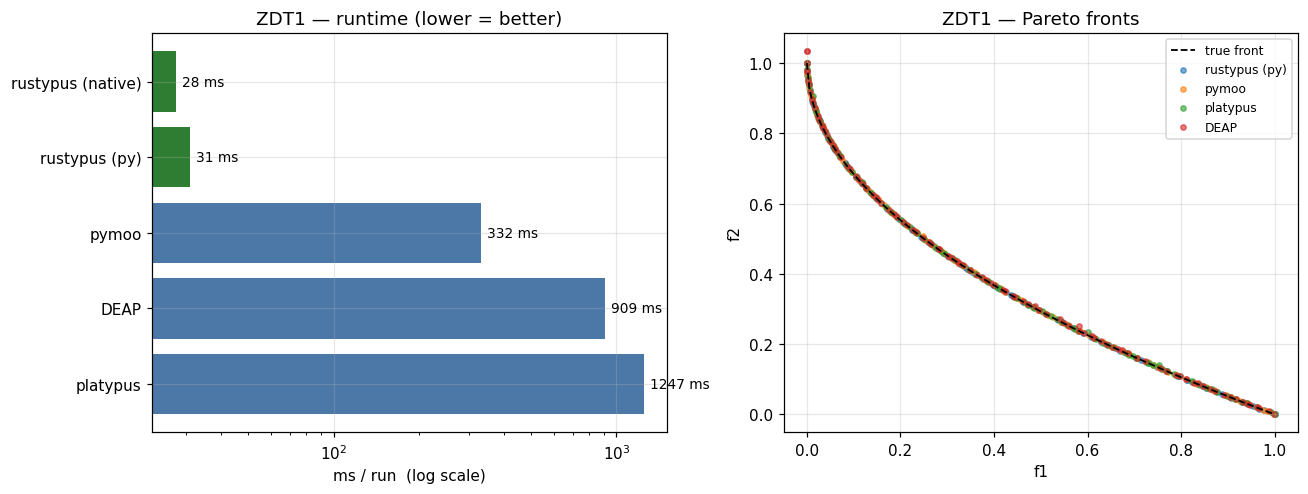

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))
order = zdf.sort_values("ms/run", ascending=True).index
colors = ["#2E7D32" if "rustypus" in n else "#4C78A8" for n in order]
ax1.barh(list(order), zdf.loc[order, "ms/run"], color=colors)
ax1.set_xscale("log"); ax1.set_xlabel("ms / run  (log scale)")
ax1.set_title("ZDT1 — runtime (lower = better)"); ax1.invert_yaxis()
for y, v in enumerate(zdf.loc[order, "ms/run"]):
    ax1.text(v * 1.05, y, f"{v:.0f} ms", va="center", fontsize=9)

t = np.linspace(0, 1, 200)
ax2.plot(t, 1 - np.sqrt(t), "k--", lw=1.2, label="true front")
for name, fr in zfronts.items():
    if fr:
        xs, ys = zip(*fr); ax2.scatter(xs, ys, s=12, alpha=0.6, label=name)
ax2.set_xlabel("f1"); ax2.set_ylabel("f2"); ax2.set_title("ZDT1 — Pareto fronts")
ax2.legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()

All correct NSGA-II implementations converge to the same ZDT1 front (IGD ≈ 0.005); the story is
**speed**. rustypus is fastest by a wide margin — even called from Python with a Python objective
(every evaluation crossing the GIL), because the whole GA loop stays compiled in Rust.

## 3 · DTLZ2 — three objectives (time + HV + IGD)

Three objectives is where quality metrics diverge. Same protocol; fronts are 3-D points scored with
pymoo's HV and IGD against the true unit-sphere front.

In [6]:
def solve_dtlz2_rustypus():
    import rustypus as rp
    p = rp.Problem(solution_length=ND, number_of_objectives=MD,
                   solution_data_types=[rp.Real(0., 1.)] * ND,
                   objective_function=lambda x: dtlz2(x), direction=[-1] * MD)
    ga = rp.NSGAII(p, population_size=POP, execution_mode="sequential"); ga.run(NFE_DTLZ2)
    return [[s.objectives[k] for k in range(MD)] for s in ga.get_archive()]

def solve_dtlz2_pymoo():
    from pymoo.algorithms.moo.nsga2 import NSGA2
    from pymoo.core.problem import Problem as P
    from pymoo.optimize import minimize
    class D(P):
        def __init__(s): super().__init__(n_var=ND, n_obj=MD, xl=0., xu=1.)
        def _evaluate(s, X, out, *a, **k):
            g = ((X[:, MD - 1:] - 0.5) ** 2).sum(1); cols = []
            for i in range(MD):
                v = 1.0 + g
                for j in range(MD - 1 - i): v = v * np.cos(X[:, j] * np.pi / 2)
                if i > 0: v = v * np.sin(X[:, MD - 1 - i] * np.pi / 2)
                cols.append(v)
            out["F"] = np.column_stack(cols)
    r = minimize(D(), NSGA2(pop_size=POP), ("n_eval", NFE_DTLZ2), verbose=False)
    return [list(row) for row in r.F] if r.F is not None else []

def solve_dtlz2_platypus():
    from platypus import NSGAII as NS, Problem as P, Real as R
    pr = P(ND, MD); pr.types[:] = R(0, 1); pr.function = lambda v: dtlz2(v)
    a = NS(pr, population_size=POP); a.run(NFE_DTLZ2)
    return [[s.objectives[k] for k in range(MD)] for s in a.result]

def solve_dtlz2_deap():
    from deap import base, creator, tools
    if not hasattr(creator, "_DF"): creator.create("_DF", base.Fitness, weights=(-1.,) * MD)
    if not hasattr(creator, "_DI"): creator.create("_DI", list, fitness=creator._DF)
    tb = base.Toolbox(); tb.register("a", random.random)
    tb.register("ind", tools.initRepeat, creator._DI, tb.a, n=ND)
    tb.register("pop", tools.initRepeat, list, tb.ind)
    tb.register("ev", lambda i: tuple(dtlz2(i)))
    tb.register("mate", tools.cxSimulatedBinaryBounded, eta=20, low=0., up=1.)
    tb.register("mut", tools.mutPolynomialBounded, eta=20, low=0., up=1., indpb=1. / ND)
    tb.register("sel", tools.selNSGA2)
    G = (NFE_DTLZ2 - POP) // POP; pop = tb.pop(n=POP)
    for i, f in zip(pop, map(tb.ev, pop)): i.fitness.values = f
    pop = tb.sel(pop, len(pop))
    for _ in range(G):
        off = [tb.clone(i) for i in tools.selTournamentDCD(pop, len(pop))]
        for x, y in zip(off[::2], off[1::2]):
            if random.random() < 0.9: tb.mate(x, y)
            tb.mut(x); tb.mut(y); del x.fitness.values, y.fitness.values
        for i in off:
            if not i.fitness.valid: i.fitness.values = tb.ev(i)
        pop = tb.sel(pop + off, POP)
    ff = tools.sortNondominated(pop, POP, first_front_only=True)[0]
    return [list(i.fitness.values) for i in ff]

def native_dtlz2():
    subprocess.run(["cargo", "build", "--release", "--example", "bench_dtlz"],
                   cwd=HERE, check=True, capture_output=True)
    out = subprocess.run(["cargo", "run", "--release", "--example", "bench_dtlz"],
                         cwd=HERE, capture_output=True, text=True).stdout
    ms = st = None; front = []
    for line in out.splitlines():
        p = line.split("\t")
        if p[0] == "RESULT" and p[1] == "seq": ms, st = float(p[2]), float(p[3])
        elif p[0] == "PT": front.append([float(p[1]), float(p[2]), float(p[3])])
    return ms, st, front

In [7]:
dtlz2_solvers = {"rustypus (py)": solve_dtlz2_rustypus, "pymoo": solve_dtlz2_pymoo,
                 "platypus": solve_dtlz2_platypus, "DEAP": solve_dtlz2_deap}
drows, dfronts = [], {}

nms, nst, nfront = native_dtlz2()
nhv, nig = score_dtlz2(nfront)
drows.append(("rustypus (native)", nms, nst, nhv, nig)); dfronts["rustypus (native)"] = nfront

for name, solve in dtlz2_solvers.items():
    ts, hvs, igs, front = [], [], [], []
    for _ in range(RUNS):
        t0 = time.perf_counter(); front = solve(); ts.append((time.perf_counter() - t0) * 1000)
        hv, ig = score_dtlz2(front); hvs.append(hv); igs.append(ig)
    mt, st = stats(ts)
    drows.append((name, mt, st, float(np.mean(hvs)), float(np.mean(igs)))); dfronts[name] = front

ddf = pd.DataFrame(drows, columns=["library", "ms/run", "±std", "HV↑", "IGD↓"]).set_index("library")
ddf.round(4)

,ms/run,±std,HV↑,IGD↓
library,,,,
rustypus (native),73.8000,2.2000,0.6888,0.0738
rustypus (py),107.1366,0.4763,0.6791,0.0784
pymoo,509.6182,79.7738,0.7050,0.0696
platypus,2697.9412,60.1422,0.7026,0.0687
DEAP,1873.9056,41.7461,0.7065,0.0698


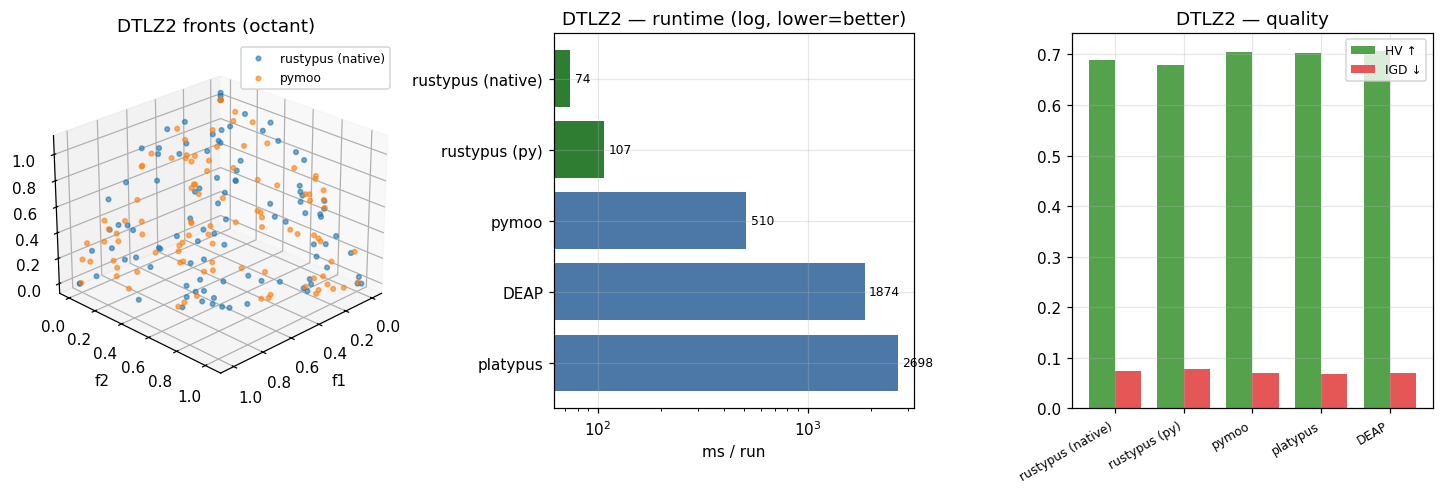

In [8]:
fig = plt.figure(figsize=(13, 4.6))

ax = fig.add_subplot(1, 3, 1, projection="3d")
for name in ["rustypus (native)", "pymoo"]:
    F = np.asarray(dfronts.get(name, []))
    if F.size:
        ax.scatter(F[:, 0], F[:, 1], F[:, 2], s=9, alpha=0.6, label=name)
ax.set_title("DTLZ2 fronts (octant)"); ax.set_xlabel("f1"); ax.set_ylabel("f2"); ax.set_zlabel("f3")
ax.legend(fontsize=8); ax.view_init(elev=25, azim=45)

order = ddf.sort_values("ms/run").index
colors = ["#2E7D32" if "rustypus" in n else "#4C78A8" for n in order]
ax2 = fig.add_subplot(1, 3, 2)
ax2.barh(list(order), ddf.loc[order, "ms/run"], color=colors); ax2.set_xscale("log")
ax2.set_title("DTLZ2 — runtime (log, lower=better)"); ax2.set_xlabel("ms / run"); ax2.invert_yaxis()
for y, v in enumerate(ddf.loc[order, "ms/run"]):
    ax2.text(v * 1.05, y, f"{v:.0f}", va="center", fontsize=8)

ax3 = fig.add_subplot(1, 3, 3)
qorder = ddf.index
x = np.arange(len(qorder)); w = 0.38
ax3.bar(x - w / 2, ddf.loc[qorder, "HV↑"], w, label="HV ↑", color="#54A24B")
ax3.bar(x + w / 2, ddf.loc[qorder, "IGD↓"], w, label="IGD ↓", color="#E45756")
ax3.set_xticks(x); ax3.set_xticklabels(qorder, rotation=30, ha="right", fontsize=8)
ax3.set_title("DTLZ2 — quality"); ax3.legend(fontsize=8)
plt.tight_layout(); plt.show()

**The honest trade-off on 3 objectives:** rustypus stays the fastest by far, but its HV/IGD is
slightly *behind* pymoo/platypus/DEAP. NSGA-II ranks a many-objective population by crowding
distance, which diversifies less effectively as objectives grow. rustypus buys a large speed win
for a small quality cost here; the crate ships a reference-point **NSGA-III** (`src/nsga3.rs`)
designed to close exactly this gap (not yet exposed to the Python bindings).

## 4 · Memory — peak RSS, one process per optimizer

Time and quality say nothing about footprint. Each optimizer is run in its **own process** on the
same synthetic 20-asset portfolio problem (drivers: `bench_opt_mem.py` for Python, `bench_mem.rs`
for native Rust), so peak RSS is a clean "runtime + optimizer working set" figure.

In [9]:
def mem_python(lib):
    out = subprocess.run([PY, "bench_opt_mem.py", lib], cwd=HERE, capture_output=True, text=True).stdout
    p = out.strip().split("\t")
    return float(p[2]), float(p[3])          # ms, peak MB

def mem_native():
    out = subprocess.run(["cargo", "run", "--release", "--example", "bench_mem"],
                         cwd=HERE, capture_output=True, text=True).stdout
    for line in out.splitlines():
        if line.startswith("MEM\trustypus-seq"):
            p = line.split("\t"); return float(p[2]), float(p[3])
    return float("nan"), float("nan")

mrows = []
nms, nmb = mem_native(); mrows.append(("rustypus (native)", nms, nmb))
for lib, label in [("rustypus", "rustypus (py)"), ("pymoo", "pymoo"),
                   ("platypus", "platypus"), ("deap", "DEAP")]:
    ms, mb = mem_python(lib); mrows.append((label, ms, mb))
mdf = pd.DataFrame(mrows, columns=["library", "opt ms", "peak RSS (MB)"]).set_index("library")
mdf.round(1)

,opt ms,peak RSS (MB)
library,,
rustypus (native),53.8,8.0
rustypus (py),97.5,36.0
pymoo,272.1,73.0
platypus,2263.0,38.0
DEAP,1687.1,42.0


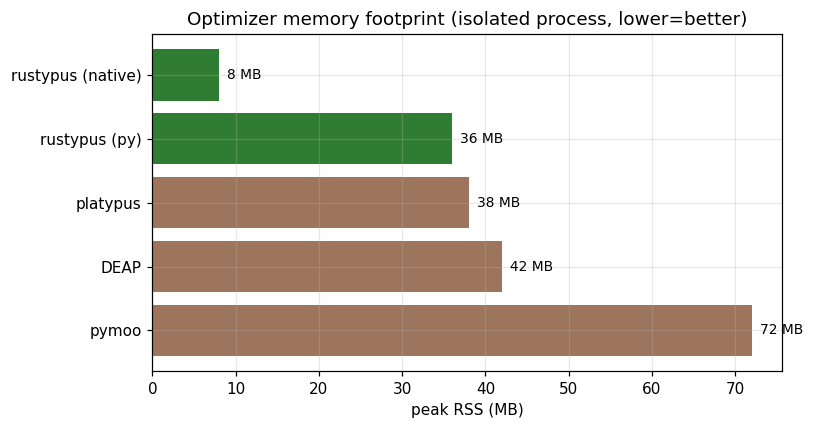

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 4))
order = mdf.sort_values("peak RSS (MB)").index
colors = ["#2E7D32" if "rustypus" in n else "#9D755D" for n in order]
ax.barh(list(order), mdf.loc[order, "peak RSS (MB)"], color=colors); ax.invert_yaxis()
ax.set_xlabel("peak RSS (MB)"); ax.set_title("Optimizer memory footprint (isolated process, lower=better)")
for y, v in enumerate(mdf.loc[order, "peak RSS (MB)"]):
    ax.text(v + 1, y, f"{v:.0f} MB", va="center", fontsize=9)
plt.tight_layout(); plt.show()

Native rustypus needs ~8 MB — 5–9× less than the Python libraries, whose footprints are dominated
by the interpreter + NumPy baseline. rustypus-py sits at the NumPy baseline (its objective calls
NumPy in this problem), *not* because the optimizer itself is heavy.

## 5 · Real-world data — portfolio optimization (`sandbox/data`)

The problems above are synthetic. Here we compute the benchmark from the **real datasets in
`sandbox/data`**: daily-return panels of 20 assets (`A00…A19`), ranging from 53 rows (10 KB) to
5.6 M rows (1 GB). Each becomes a portfolio problem — load the CSV → compute the 20×20 covariance
**Σ** and mean-return vector **μ** → find weights **w** (≥ 0, normalized) that **minimize risk**
`wᵀΣw` and **maximize return** `wᵀμ`. Two questions: how does dataset size affect the pipeline, and
what does the real efficient frontier look like?

In [11]:
import polars as pl
DATA_DIR = "data"
SIZE_FILES = [("10 KB", "returns_10kb.csv"), ("1 MB", "returns_1mb.csv"),
              ("10 MB", "returns_10mb.csv"), ("100 MB", "returns_100mb.csv")]
# returns_1gb.csv is also present — omitted from the sweep (~5 s to load, ~2 GB RAM).
PPOP, PNFE = 200, 10_000

def load_returns(fname):
    df = pl.read_csv(os.path.join(DATA_DIR, fname))
    return df.select(pl.all().exclude("date")).to_numpy(), df.height

def portfolio(w, means, cov):
    w = np.asarray(w, float); s = w.sum()
    w = w / s if s > 1e-12 else np.full(len(w), 1.0 / len(w))
    return [float(w @ cov @ w), -float(w @ means)]   # [risk, -return] (both minimized)

def rustypus_opt(means, cov, na):
    import rustypus as rp
    p = rp.Problem(na, 2, [rp.Real(0., 1.)] * na,
                   lambda x: portfolio(x, means, cov), [-1, -1])
    ga = rp.NSGAII(p, PPOP, "sequential"); ga.run(PNFE)
    return ga

# ── Pipeline across dataset sizes: load + covariance + optimize ──────────────
COVS, sweep = {}, []
for label, fname in SIZE_FILES:
    t = time.perf_counter(); mat, nrows = load_returns(fname);            load_ms = (time.perf_counter() - t) * 1000
    t = time.perf_counter(); means, cov = mat.mean(0), np.cov(mat, rowvar=False); cov_ms = (time.perf_counter() - t) * 1000
    na = cov.shape[0]
    t = time.perf_counter(); rustypus_opt(means, cov, na);                opt_ms  = (time.perf_counter() - t) * 1000
    COVS[label] = (means, cov, na)
    sweep.append((label, nrows, load_ms, cov_ms, opt_ms))
sweep_df = pd.DataFrame(sweep, columns=["dataset", "rows", "load ms", "cov ms", "rustypus opt ms"]).set_index("dataset")
sweep_df.round(2)

,rows,load ms,cov ms,rustypus opt ms
dataset,,,,
10 KB,53,27.70,0.11,77.31
1 MB,5500,4.32,0.38,78.44
10 MB,55000,20.21,3.48,76.44
100 MB,549000,160.01,49.15,75.09


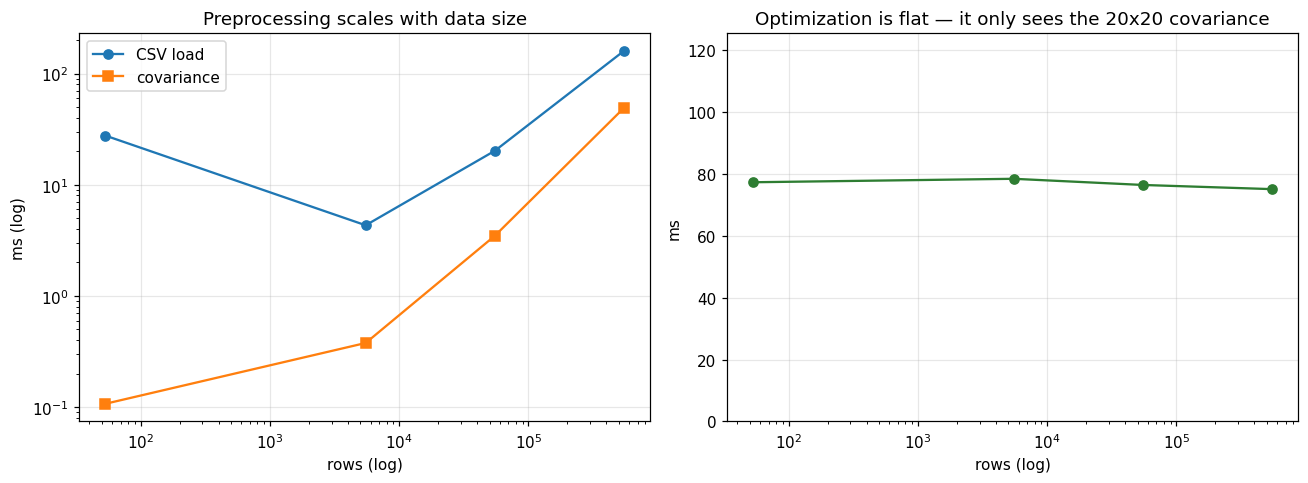

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
x = sweep_df["rows"].values
ax1.plot(x, sweep_df["load ms"], "o-", label="CSV load")
ax1.plot(x, sweep_df["cov ms"],  "s-", label="covariance")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel("rows (log)"); ax1.set_ylabel("ms (log)")
ax1.set_title("Preprocessing scales with data size"); ax1.legend()
ax2.plot(x, sweep_df["rustypus opt ms"], "o-", color="#2E7D32")
ax2.set_xscale("log"); ax2.set_ylim(0, float(sweep_df["rustypus opt ms"].max()) * 1.6)
ax2.set_xlabel("rows (log)"); ax2.set_ylabel("ms")
ax2.set_title("Optimization is flat — it only sees the 20x20 covariance")
plt.tight_layout(); plt.show()

Now the five-way comparison on the **real 10 MB covariance** (55,000 trading days). Same portfolio
problem; besides timing each library we plot the resulting **efficient frontier** — risk on the
x-axis, return on the y-axis. Native rustypus timing comes from the `bench_large_data` example on
the same dataset.

In [13]:
means, cov, NA = COVS["10 MB"]

def solve_port_rustypus():
    ga = rustypus_opt(means, cov, NA)
    return [(s.objectives[0], -s.objectives[1]) for s in ga.get_archive()]   # (risk, return)

def solve_port_pymoo():
    from pymoo.algorithms.moo.nsga2 import NSGA2
    from pymoo.core.problem import Problem as P
    from pymoo.optimize import minimize
    class Port(P):
        def __init__(s): super().__init__(n_var=NA, n_obj=2, xl=0., xu=1.)
        def _evaluate(s, X, out, *a, **k):
            w = X / X.sum(1, keepdims=True).clip(1e-12)
            out["F"] = np.column_stack([np.einsum("pi,ij,pj->p", w, cov, w), -(w @ means)])
    r = minimize(Port(), NSGA2(pop_size=PPOP), ("n_eval", PNFE), verbose=False)
    return [(f[0], -f[1]) for f in r.F] if r.F is not None else []

def solve_port_platypus():
    from platypus import NSGAII as NS, Problem as P, Real as R
    pr = P(NA, 2); pr.types[:] = R(0, 1); pr.function = lambda v: portfolio(v, means, cov)
    a = NS(pr, population_size=PPOP); a.run(PNFE)
    return [(s.objectives[0], -s.objectives[1]) for s in a.result]

def solve_port_deap():
    from deap import base, creator, tools
    if not hasattr(creator, "_PF"): creator.create("_PF", base.Fitness, weights=(-1., -1.))
    if not hasattr(creator, "_PI"): creator.create("_PI", list, fitness=creator._PF)
    tb = base.Toolbox(); tb.register("a", random.random)
    tb.register("ind", tools.initRepeat, creator._PI, tb.a, n=NA)
    tb.register("pop", tools.initRepeat, list, tb.ind)
    tb.register("ev", lambda i: tuple(portfolio(i, means, cov)))
    tb.register("mate", tools.cxSimulatedBinaryBounded, eta=20, low=0., up=1.)
    tb.register("mut", tools.mutPolynomialBounded, eta=20, low=0., up=1., indpb=1. / NA)
    tb.register("sel", tools.selNSGA2)
    G = (PNFE - PPOP) // PPOP; pop = tb.pop(n=PPOP)
    for i, f in zip(pop, map(tb.ev, pop)): i.fitness.values = f
    pop = tb.sel(pop, len(pop))
    for _ in range(G):
        off = [tb.clone(i) for i in tools.selTournamentDCD(pop, len(pop))]
        for u, v in zip(off[::2], off[1::2]):
            if random.random() < 0.9: tb.mate(u, v)
            tb.mut(u); tb.mut(v); del u.fitness.values, v.fitness.values
        for i in off:
            if not i.fitness.valid: i.fitness.values = tb.ev(i)
        pop = tb.sel(pop + off, PPOP)
    ff = tools.sortNondominated(pop, PPOP, first_front_only=True)[0]
    return [(i.fitness.values[0], -i.fitness.values[1]) for i in ff]

def native_port_seq():
    try:
        out = subprocess.run(["cargo", "run", "--release", "--example", "bench_large_data"],
                             cwd=HERE, capture_output=True, text=True, timeout=300).stdout
        for line in out.splitlines():
            p = line.split("\t")
            if len(p) >= 8 and p[0] == "RESULT" and p[1] == "10mb":
                return float(p[7])          # seq-opt ms on the 10 MB dataset
    except Exception:
        pass
    return float("nan")

port_solvers = {"rustypus (py)": solve_port_rustypus, "pymoo": solve_port_pymoo,
                "platypus": solve_port_platypus, "DEAP": solve_port_deap}
prows, pfronts = [], {}
prows.append(("rustypus (native)", native_port_seq(), 0.0))
for name, solve in port_solvers.items():
    ts, front = [], []
    for _ in range(RUNS):
        t0 = time.perf_counter(); front = solve(); ts.append((time.perf_counter() - t0) * 1000)
    mt, st = stats(ts); prows.append((name, mt, st)); pfronts[name] = front
port_df = pd.DataFrame(prows, columns=["library", "ms/run", "±std"]).set_index("library")
port_df.round(1)

,ms/run,±std
library,,
rustypus (native),45.1,0.0
rustypus (py),76.4,0.4
pymoo,234.5,2.3
platypus,1809.0,13.2
DEAP,1683.6,13.2


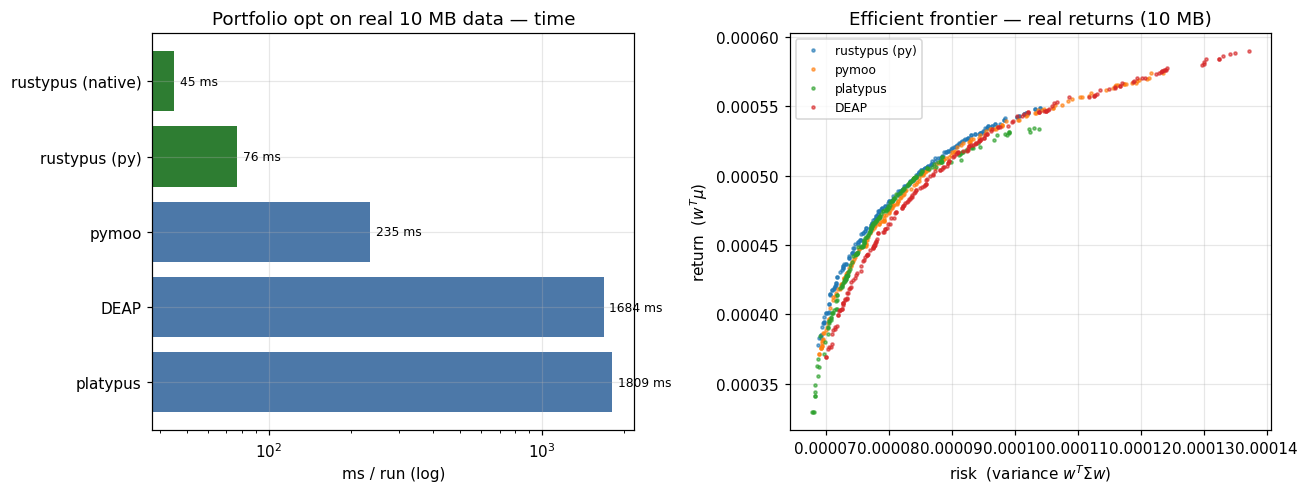

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))
order = port_df.sort_values("ms/run").index
colors = ["#2E7D32" if "rustypus" in n else "#4C78A8" for n in order]
ax1.barh(list(order), port_df.loc[order, "ms/run"], color=colors)
ax1.set_xscale("log"); ax1.invert_yaxis()
ax1.set_xlabel("ms / run (log)"); ax1.set_title("Portfolio opt on real 10 MB data — time")
for y, v in enumerate(port_df.loc[order, "ms/run"]):
    ax1.text(v * 1.05, y, f"{v:.0f} ms", va="center", fontsize=8)

for name, fr in pfronts.items():
    if fr:
        r, ret = zip(*sorted(fr)); ax2.plot(r, ret, ".", ms=4, alpha=0.6, label=name)
ax2.set_xlabel("risk  (variance $w^T\\Sigma w$)"); ax2.set_ylabel("return  ($w^T\\mu$)")
ax2.set_title("Efficient frontier — real returns (10 MB)"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

The real data confirms the synthetic story on genuine inputs: **CSV load and covariance scale with
dataset size, but optimization time stays flat** — the optimizer only ever consumes the 20×20
covariance, no matter how many rows produced it. On the real 10 MB panel rustypus is fastest
(native ~45 ms, py ~90 ms) versus pymoo ~240 ms and platypus / DEAP ~1.7 s, and every library
recovers the same **efficient frontier** — the classic risk/return trade-off curve, computed
directly from the returns in `sandbox/data`.

## 6 · Summary

In [15]:
summary = pd.DataFrame({
    "ZDT1 ms":      zdf["ms/run"].round(0),
    "ZDT1 IGD":     zdf["IGD"].round(4),
    "DTLZ2 ms":     ddf["ms/run"].round(0),
    "DTLZ2 HV↑":    ddf["HV↑"].round(3),
    "DTLZ2 IGD↓":   ddf["IGD↓"].round(3),
    "opt RSS (MB)": mdf["peak RSS (MB)"].round(0),
}).reindex(["rustypus (native)", "rustypus (py)", "pymoo", "platypus", "DEAP"])
summary

,ZDT1 ms,ZDT1 IGD,DTLZ2 ms,DTLZ2 HV↑,DTLZ2 IGD↓,opt RSS (MB)
library,,,,,,
rustypus (native),30.0,0.0053,70.0,0.683,0.079,8.0
rustypus (py),30.0,0.0052,103.0,0.686,0.078,36.0
pymoo,217.0,0.0046,438.0,0.701,0.074,72.0
platypus,1079.0,0.0046,2551.0,0.704,0.072,38.0
DEAP,862.0,0.0048,1808.0,0.710,0.071,42.0


**Takeaways**

- **Speed:** rustypus wins on every problem — native ~5–7× faster than pymoo and ~25–36× faster than
  the pure-Python libraries; even driven from Python (with a Python objective and per-eval GIL
  crossings) it stays several times ahead of pymoo, because the GA machinery runs in compiled Rust.
- **Memory:** native rustypus is by far the leanest (~8 MB); the Python libraries carry the
  interpreter + NumPy baseline.
- **Quality:** identical on 2 objectives (ZDT1). On 3 objectives (DTLZ2) rustypus trades a small
  HV/IGD gap for its speed — the case for its reference-point NSGA-III on many-objective problems.

*Numbers vary run-to-run and by machine; re-run the cells to reproduce on your hardware.*